# Imports ...

In [2]:

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import DataLoader
from torchvision import datasets, transforms

import matplotlib.pyplot as plt
import numpy as np


# Device 

In [ ]:


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", device)


# Hyper parameters 

In [3]:


batch_size = 128
latent_dim = 16

epochs = 20
lr = 1e-3

beta = 1e-3


# MNIST DATASET


In [4]:


transform = transforms.ToTensor()

train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)


# VAE MODEL


In [5]:


class VAE(nn.Module):

    def __init__(self, latent_dim):

        super().__init__()

        # ====================================================
        # ENCODER
        # ====================================================

        self.encoder = nn.Sequential(

            nn.Linear(28 * 28, 512),
            nn.ReLU(),

            nn.Linear(512, 256),
            nn.ReLU()

        )

        # ====================================================
        # LATENT PARAMETERS
        # ====================================================

        self.mu = nn.Linear(256, latent_dim)

        self.logvar = nn.Linear(256, latent_dim)

        # ====================================================
        # DECODER
        # ====================================================

        self.decoder = nn.Sequential(

            nn.Linear(latent_dim, 256),
            nn.ReLU(),

            nn.Linear(256, 512),
            nn.ReLU(),

            nn.Linear(512, 28 * 28),

            nn.Sigmoid()

        )

    # ========================================================
    # REPARAMETERIZATION
    # ========================================================

    def reparameterize(self, mu, logvar):

        std = torch.exp(0.5 * logvar)

        eps = torch.randn_like(std)

        z = mu + eps * std

        return z

    # ========================================================
    # FORWARD
    # ========================================================

    def forward(self, x):

        x = x.view(-1, 28 * 28)

        h = self.encoder(x)

        mu = self.mu(h)

        logvar = self.logvar(h)

        z = self.reparameterize(mu, logvar)

        xhat = self.decoder(z)

        return xhat, mu, logvar, z


# Initialize the model and optimizer 

In [6]:


model = VAE(latent_dim).to(device)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=lr
)



# LOSS FUNCTION


In [7]:


def vae_loss(x, xhat, mu, logvar):

    # ========================================================
    # RECONSTRUCTION LOSS
    # ========================================================

    recon_loss = F.binary_cross_entropy(
        xhat,
        x.view(-1, 28 * 28),
        reduction='mean'
    )

    # ========================================================
    # KL LOSS
    # ========================================================

    kl_loss = -0.5 * torch.mean(
        1 + logvar - mu.pow(2) - logvar.exp()
    )

    total_loss = recon_loss + beta * kl_loss

    return total_loss, recon_loss, kl_loss



# TRAINING


In [8]:


total_losses = []
recon_losses = []
kl_losses = []

print("\nTraining VAE...\n")

for epoch in range(epochs):

    total_epoch = 0.0
    recon_epoch = 0.0
    kl_epoch = 0.0

    for images, _ in loader:

        images = images.to(device)

        xhat, mu, logvar, z = model(images)

        loss, recon, kl = vae_loss(
            images,
            xhat,
            mu,
            logvar
        )

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        total_epoch += loss.item()
        recon_epoch += recon.item()
        kl_epoch += kl.item()

    avg_total = total_epoch / len(loader)
    avg_recon = recon_epoch / len(loader)
    avg_kl = kl_epoch / len(loader)

    total_losses.append(avg_total)
    recon_losses.append(avg_recon)
    kl_losses.append(avg_kl)

    print(
        f"Epoch [{epoch+1}/{epochs}] "
        f"Total: {avg_total:.6f} "
        f"Recon: {avg_recon:.6f} "
        f"KL: {avg_kl:.6f}"
    )



Training VAE...

Epoch [1/20] Total: 0.192641 Recon: 0.190221 KL: 2.420203
Epoch [2/20] Total: 0.120445 Recon: 0.116831 KL: 3.613761
Epoch [3/20] Total: 0.105741 Recon: 0.102112 KL: 3.628579
Epoch [4/20] Total: 0.100322 Recon: 0.096772 KL: 3.549994
Epoch [5/20] Total: 0.097309 Recon: 0.093816 KL: 3.492594
Epoch [6/20] Total: 0.095366 Recon: 0.091917 KL: 3.449005
Epoch [7/20] Total: 0.093906 Recon: 0.090484 KL: 3.421543
Epoch [8/20] Total: 0.092810 Recon: 0.089407 KL: 3.403139
Epoch [9/20] Total: 0.091886 Recon: 0.088500 KL: 3.386006
Epoch [10/20] Total: 0.091119 Recon: 0.087743 KL: 3.375787
Epoch [11/20] Total: 0.090458 Recon: 0.087092 KL: 3.366505
Epoch [12/20] Total: 0.089948 Recon: 0.086584 KL: 3.363882
Epoch [13/20] Total: 0.089418 Recon: 0.086062 KL: 3.355786
Epoch [14/20] Total: 0.088939 Recon: 0.085588 KL: 3.350617
Epoch [15/20] Total: 0.088579 Recon: 0.085231 KL: 3.347107
Epoch [16/20] Total: 0.088208 Recon: 0.084863 KL: 3.345269
Epoch [17/20] Total: 0.087911 Recon: 0.084568 K

# Loss plot 

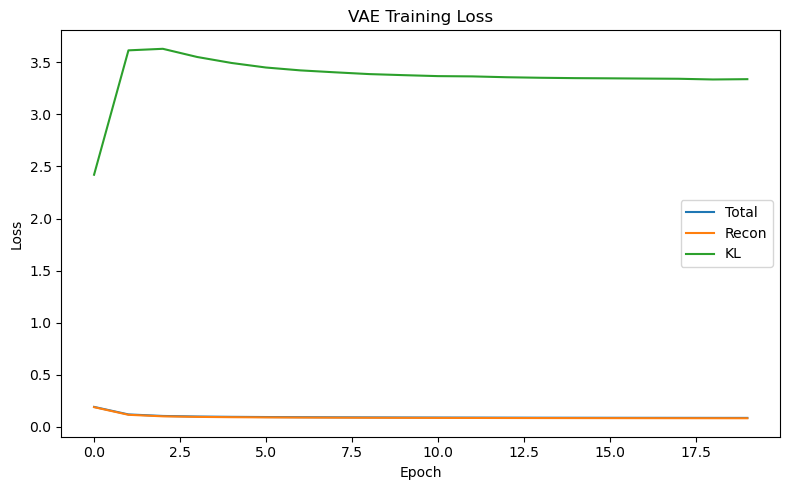


Training complete.


In [9]:

plt.figure(figsize=(8,5))

plt.plot(total_losses, label="Total")
plt.plot(recon_losses, label="Recon")
plt.plot(kl_losses, label="KL")

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title("VAE Training Loss")

plt.legend()

plt.tight_layout()

plt.savefig("loss_curve.png", dpi=300)

plt.show()

print("\nTraining complete.")


# SAVE MODEL



In [ ]:

torch.save(model.state_dict(), "mnist_vae.pt")

print("\nModel saved.")


# LATENT SPACE VISUALIZATION


In [11]:


if latent_dim >= 2:

    latent_vectors = []
    labels = []

    with torch.no_grad():

        for images, y in loader:

            images = images.to(device)

            _, mu, _, _ = model(images)

            latent_vectors.append(mu.cpu().numpy())

            labels.append(y.numpy())

    latent_vectors = np.concatenate(latent_vectors)
    labels = np.concatenate(labels)


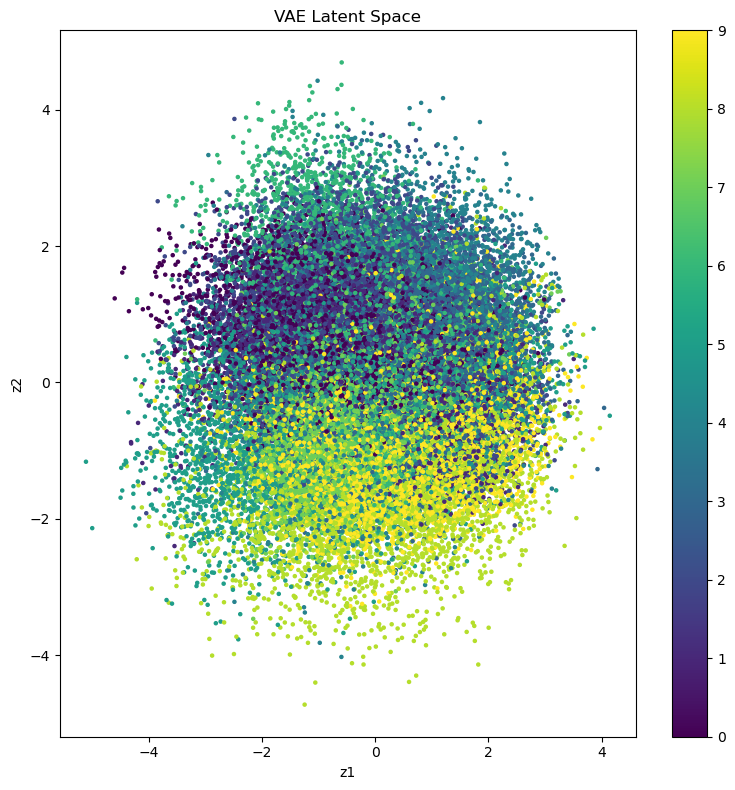

In [15]:
plt.figure(figsize=(8,8))

scatter = plt.scatter(

        latent_vectors[:,0],
        latent_vectors[:,1],

        c=labels,
        s=5
    )

plt.colorbar(scatter)

plt.xlabel("z1")
plt.ylabel("z2")

plt.title("VAE Latent Space")

plt.tight_layout()

plt.savefig("latent_space.png", dpi=300)

# Generate samples 

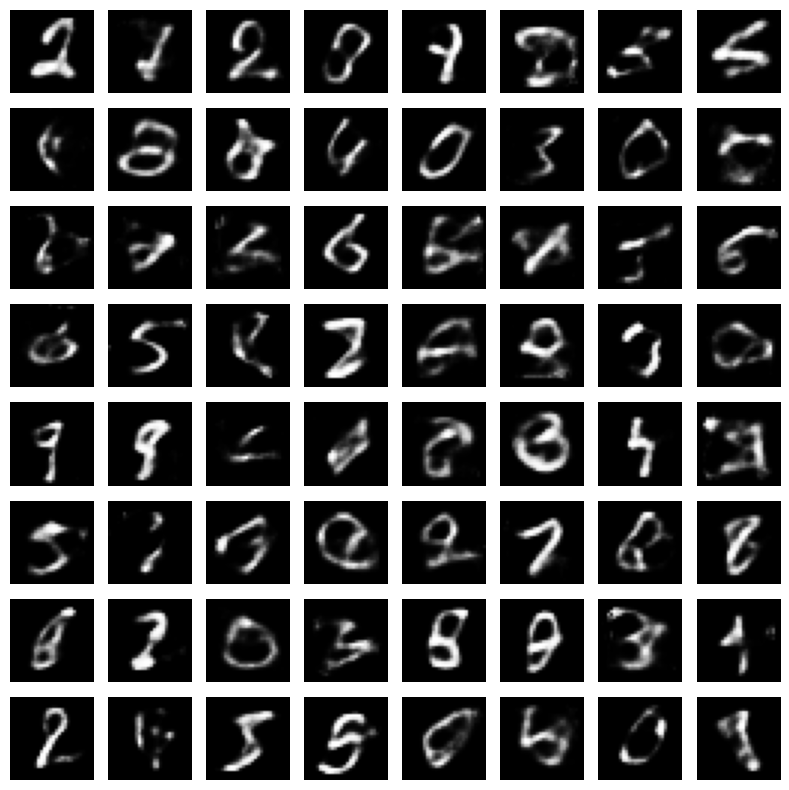

In [16]:
# ============================================================
# GENERATE NEW DIGITS
# ============================================================

model.eval()

with torch.no_grad():

    z = torch.randn(64, latent_dim).to(device)

    generated = model.decoder(z)

generated = generated.cpu().numpy()

# ============================================================
# PLOT GENERATED DIGITS
# ============================================================

fig, axes = plt.subplots(8, 8, figsize=(8,8))

for i, ax in enumerate(axes.flat):

    img = generated[i].reshape(28,28)

    ax.imshow(img, cmap='gray')

    ax.axis("off")

plt.tight_layout()

plt.savefig("generated_digits.png", dpi=300)


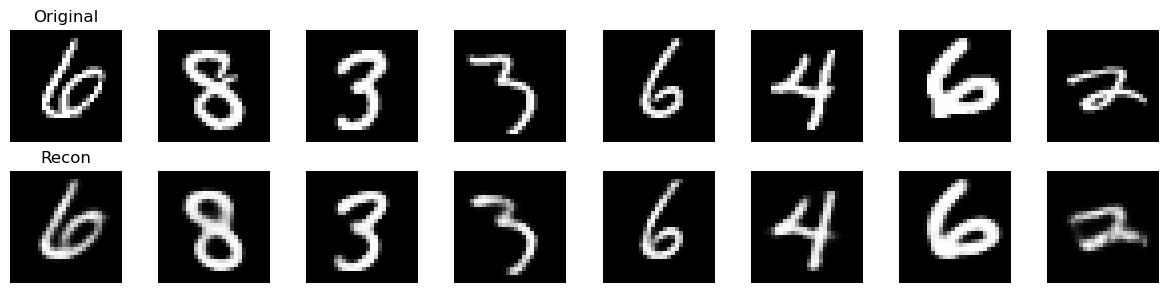

In [17]:

# ============================================================
# RECONSTRUCTIONS
# ============================================================

with torch.no_grad():

    images, _ = next(iter(loader))

    images = images.to(device)

    xhat, _, _, _ = model(images)

original = images[:8].cpu().numpy()
reconstructed = xhat[:8].cpu().numpy()

# ============================================================
# PLOT RECONSTRUCTIONS
# ============================================================

fig, axes = plt.subplots(2, 8, figsize=(12,3))

for i in range(8):

    axes[0,i].imshow(
        original[i].reshape(28,28),
        cmap='gray'
    )

    axes[0,i].axis("off")

    axes[1,i].imshow(
        reconstructed[i].reshape(28,28),
        cmap='gray'
    )

    axes[1,i].axis("off")

axes[0,0].set_title("Original")
axes[1,0].set_title("Recon")

plt.tight_layout()

plt.savefig("reconstruction.png", dpi=300)


